<a href="https://colab.research.google.com/github/Vikasgzp/-hvac-fault-detection-/blob/main/CyberThreat.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import glob

csv_files = glob.glob("/content/*.csv")

print("Number of files:", len(csv_files))

df_list = []

for file in csv_files:
    print("Loading:", file)

    temp_df = pd.read_csv(
        file,
        low_memory=False
    )

    df_list.append(temp_df)

df = pd.concat(
    df_list,
    ignore_index=True
)

print("Merged Shape:", df.shape)

Number of files: 7
Loading: /content/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Loading: /content/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Loading: /content/Tuesday-WorkingHours.pcap_ISCX.csv
Loading: /content/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Loading: /content/Friday-WorkingHours-Morning.pcap_ISCX.csv
Loading: /content/Monday-WorkingHours.pcap_ISCX.csv
Loading: /content/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Merged Shape: (2138040, 79)


In [2]:
print(df.columns.tolist())

[' Destination Port', ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets', 'Total Length of Fwd Packets', ' Total Length of Bwd Packets', ' Fwd Packet Length Max', ' Fwd Packet Length Min', ' Fwd Packet Length Mean', ' Fwd Packet Length Std', 'Bwd Packet Length Max', ' Bwd Packet Length Min', ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s', ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean', ' Packet Length Std', ' Packet Length Variance', 'FIN Flag Count', ' SYN Flag Count', ' RST Flag Count', ' PSH Flag Count', ' ACK Flag Count', ' URG Flag 

In [3]:
df.columns = df.columns.str.strip()

In [4]:
print(df.columns.tolist())

['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'ECE Flag Count

In [5]:
print(df["Label"].value_counts())

Label
BENIGN                        1833066
PortScan                       158930
DDoS                           128027
FTP-Patator                      7938
SSH-Patator                      5897
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Name: count, dtype: int64


In [6]:
df.to_csv(
    "cicids2017_merged.csv",
    index=False
)

In [7]:
df = df.sample(
    n=100000,
    random_state=42
)

In [9]:
df.to_csv(
    "cicids2017_300k.csv",
    index=False
)

In [10]:
print(df.shape)

print(df.columns.tolist())

print(df["Label"].value_counts())

(100000, 79)
['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'E

**Problem 1: Extreme Class Imbalance**

My dataset is heavily skewed.

For example:

BENIGN:      85,877

SQL Injection:     1

No model can learn from a class that appears only once.

For Version 1 of the project:

Keep only the major classes:

In [11]:
major_classes = [
    "BENIGN",
    "PortScan",
    "DDoS",
    "FTP-Patator",
    "SSH-Patator",
    "Bot"
]

df = df[df["Label"].isin(major_classes)]

In [12]:
print(df["Label"].value_counts())

Label
BENIGN         85877
PortScan        7286
DDoS            5988
FTP-Patator      370
SSH-Patator      269
Bot               95
Name: count, dtype: int64


**Step 1: Clean Data**

In [13]:
import numpy as np

df.replace(
    [np.inf, -np.inf],
    np.nan,
    inplace=True
)

df.dropna(inplace=True)

**Step 3: Remove Duplicates**

In [14]:
df.drop_duplicates(inplace=True)

print(df.shape)

(97729, 79)


**Step 4: Encode Labels**

In [15]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df["Label"] = encoder.fit_transform(df["Label"])

print(dict(
    zip(
        encoder.classes_,
        encoder.transform(encoder.classes_)
    )
))

{'BENIGN': np.int64(0), 'Bot': np.int64(1), 'DDoS': np.int64(2), 'FTP-Patator': np.int64(3), 'PortScan': np.int64(4), 'SSH-Patator': np.int64(5)}


In [16]:
import joblib

joblib.dump(
    encoder,
    "label_encoder.pkl"
)

['label_encoder.pkl']

In [17]:
from sklearn.model_selection import train_test_split

X = df.drop("Label", axis=1)

y = df["Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

joblib.dump(
    scaler,
    "scaler.pkl"
)

['scaler.pkl']

In [19]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [20]:
from sklearn.metrics import classification_report

preds = rf.predict(X_test)

print(
    classification_report(
        y_test,
        preds
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     16834
           1       0.86      0.32      0.46        19
           2       1.00      1.00      1.00      1198
           3       1.00      0.98      0.99        62
           4       0.99      0.99      0.99      1392
           5       1.00      0.98      0.99        41

    accuracy                           1.00     19546
   macro avg       0.97      0.88      0.90     19546
weighted avg       1.00      1.00      1.00     19546



In [21]:
print(encoder.classes_)

['BENIGN' 'Bot' 'DDoS' 'FTP-Patator' 'PortScan' 'SSH-Patator']


In [22]:

joblib.dump(rf, "random_forest_baseline.pkl")

['random_forest_baseline.pkl']

In [23]:
print(df.shape)

print(df["Label"].value_counts())

(97729, 79)
Label
0    84172
4     6962
2     5988
3      310
5      204
1       93
Name: count, dtype: int64


**`FT-Transformer Notebook`**

In [24]:
!pip install torch
!pip install pytorch-tabular

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.8/165.8 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 61.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 62.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.3/165.3 kB 20.8 MB/s eta 0:00:00


In [25]:
X = df.drop("Label", axis=1)
y = df["Label"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

train_df = X_train.copy()
train_df["Label"] = y_train

test_df = X_test.copy()
test_df["Label"] = y_test

In [26]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

print(weights)

[  0.19350887 176.08783784   2.72035491  52.54233871   2.33940754
  79.94171779]


In [27]:
from pytorch_tabular import TabularModel
from pytorch_tabular.models.ft_transformer.config import FTTransformerConfig
from pytorch_tabular.config import DataConfig
from pytorch_tabular.config import TrainerConfig
from pytorch_tabular.config import OptimizerConfig

In [28]:
target = ["Label"]

continuous_cols = [
    col
    for col in train_df.columns
    if col != "Label"
]

data_config = DataConfig(
    target=target,
    continuous_cols=continuous_cols
)

In [29]:
model_config = FTTransformerConfig(
    task="classification",
    learning_rate=1e-3,
    input_embed_dim=32,
    num_heads=8,
    num_attn_blocks=4,
    metrics=["accuracy"],
)

In [30]:
trainer_config = TrainerConfig(
    auto_lr_find=False,
    batch_size=1024,
    max_epochs=20
)

In [31]:
optimizer_config = OptimizerConfig()

In [32]:
tabular_model = TabularModel(
    data_config=data_config,
    model_config=model_config,
    optimizer_config=optimizer_config,
    trainer_config=trainer_config
)

2026-06-22 22:21:02,746 - {pytorch_tabular.tabular_model:145} - INFO - Experiment Tracking is turned off


In [33]:
tabular_model.fit(
    train=train_df,
    validation=test_df
)

INFO:lightning_fabric.utilities.seed:Seed set to 42
2026-06-22 22:21:11,407 - {pytorch_tabular.tabular_model:547} - INFO - Preparing the DataLoaders
2026-06-22 22:21:11,469 - {pytorch_tabular.tabular_datamodule:527} - INFO - Setting up the datamodule for classification task
/usr/local/lib/python3.12/dist-packages/pytorch_tabular/tabular_datamodule.py:388: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 2.20982896 -0.31612957 -0.46944671 ... -0.46944671 -0.44914325
 -0.46804109]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.loc[:, self.config.continuous_cols] = self.scaler.fit_transform(
/usr/local/lib/python3.12/dist-packages/pytorch_tabular/tabular_datamodule.py:388: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.36793935 -0.36798549 -0.36690307 ... -0.3679798  -0.34680281
  3.62005749]' has 

┏━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name             ┃ Type                  ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ _backbone        │ FTTransformerBackbone │  181 K │ train │     0 │
│ 1 │ _embedding_layer │ Embedding2dLayer      │  5.1 K │ train │     0 │
│ 2 │ _head            │ LinearHead            │    198 │ train │     0 │
│ 3 │ loss             │ CrossEntropyLoss      │      0 │ train │     0 │
└───┴──────────────────┴───────────────────────┴────────┴───────┴───────┘

Trainable params: 186 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 186 K                                                                                                
Total estimated model params size (MB): 0.746                                                                      
Modules in train mode: 86                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

2026-06-22 22:23:49,170 - {pytorch_tabular.tabular_model:690} - INFO - Training the model completed
2026-06-22 22:23:49,171 - {pytorch_tabular.tabular_model:1531} - INFO - Loading the best model


In [34]:
preds = tabular_model.predict(test_df)

/usr/local/lib/python3.12/dist-packages/pytorch_tabular/tabular_datamodule.py:392: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 2.09961762 -0.46944671 -0.36058894 ... -0.46944671  2.24179389
 -0.46944671]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.loc[:, self.config.continuous_cols] = self.scaler.transform(data.loc[:, self.config.continuous_cols])
/usr/local/lib/python3.12/dist-packages/pytorch_tabular/tabular_datamodule.py:392: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.36798504 -0.36797825 -0.36798662 ... -0.367981   -0.36798659
 -0.36688124]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.loc[:, self.config.continuous_cols] = self.scaler.transform(data.loc[:, self.config.continuous_cols])
/usr/local/lib/python3.12/dist-packages/pytorc

In [36]:
print(preds.head())

         Label_0_probability  Label_1_probability  Label_2_probability  \
1128266             0.996434             0.000399             0.000420   
857337              0.998271             0.000360             0.000224   
1990447             0.990452             0.000519             0.000147   
932937              0.000149             0.000214             0.996916   
1867415             0.998565             0.000340             0.000225   

         Label_3_probability  Label_4_probability  Label_5_probability  \
1128266             0.000305             0.000109             0.002333   
857337              0.000253             0.000141             0.000751   
1990447             0.001146             0.000657             0.007079   
932937              0.000807             0.000711             0.001203   
1867415             0.000194             0.000209             0.000467   

         Label_prediction  
1128266                 0  
857337                  0  
1990447                 0 

In [37]:
print(preds.columns)

Index(['Label_0_probability', 'Label_1_probability', 'Label_2_probability',
       'Label_3_probability', 'Label_4_probability', 'Label_5_probability',
       'Label_prediction'],
      dtype='object')


In [38]:
from sklearn.metrics import classification_report

print(
    classification_report(
        test_df["Label"],
        preds["Label_prediction"]
    )
)

              precision    recall  f1-score   support

           0       0.95      1.00      0.97     16834
           1       0.00      0.00      0.00        19
           2       0.97      0.97      0.97      1198
           3       0.00      0.00      0.00        62
           4       0.97      0.48      0.65      1392
           5       0.00      0.00      0.00        41

    accuracy                           0.95     19546
   macro avg       0.48      0.41      0.43     19546
weighted avg       0.95      0.95      0.94     19546



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [39]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(
    test_df["Label"],
    preds["Label_prediction"]
)

print("Accuracy:", acc)

Accuracy: 0.95206180292643


In [40]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    test_df["Label"],
    preds["Label_prediction"]
)


In [41]:
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[16774     0    39     0    21     0]
 [   19     0     0     0     0     0]
 [   38     0  1160     0     0     0]
 [   62     0     0     0     0     0]
 [  717     0     0     0   675     0]
 [   41     0     0     0     0     0]]


In [42]:
!pip install shap

In [43]:
tabular_model.save_model(
    "ft_transformer_model"
)

INFO:pytorch_lightning.trainer.connectors.checkpoint_connector:`weights_only` was not set, defaulting to `False`.


In [44]:
import shap

explainer = shap.TreeExplainer(rf)

shap_values = explainer.shap_values(X_test[:100])

/tmp/ipykernel_16609/291123304.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:743: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:743: FutureWarning: The NumPy gl

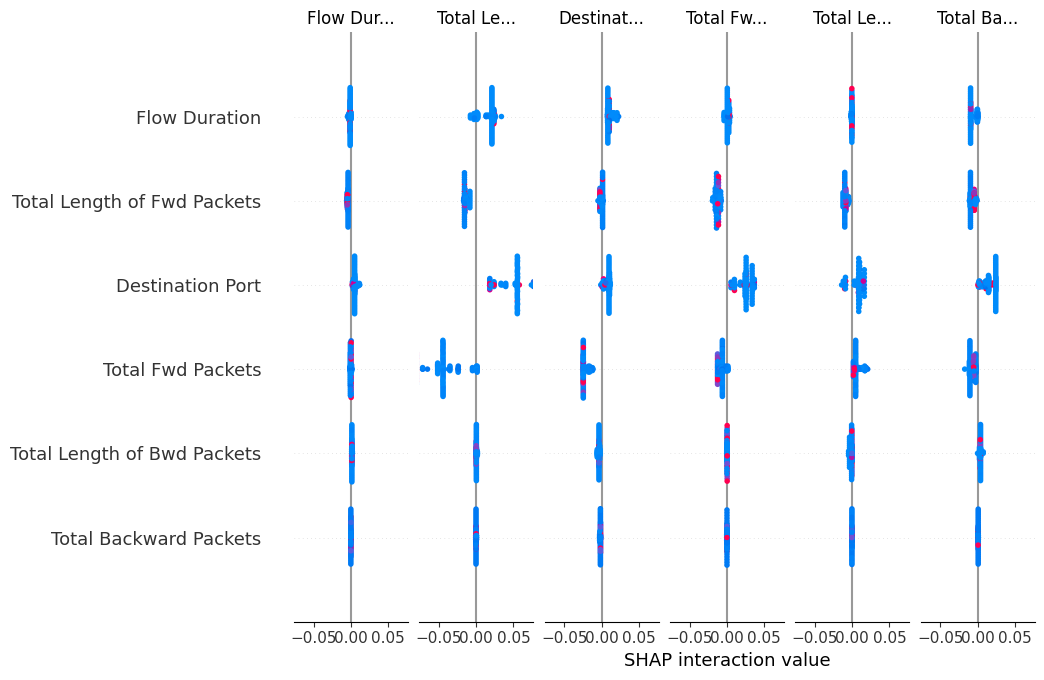

In [45]:
shap.summary_plot(
    shap_values,
    X_test[:100]
)

In [47]:
sample = X_test[:500]

In [48]:
shap_values = explainer.shap_values(sample)

/tmp/ipykernel_16609/2612720054.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:743: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:743: FutureWarning: The NumPy g

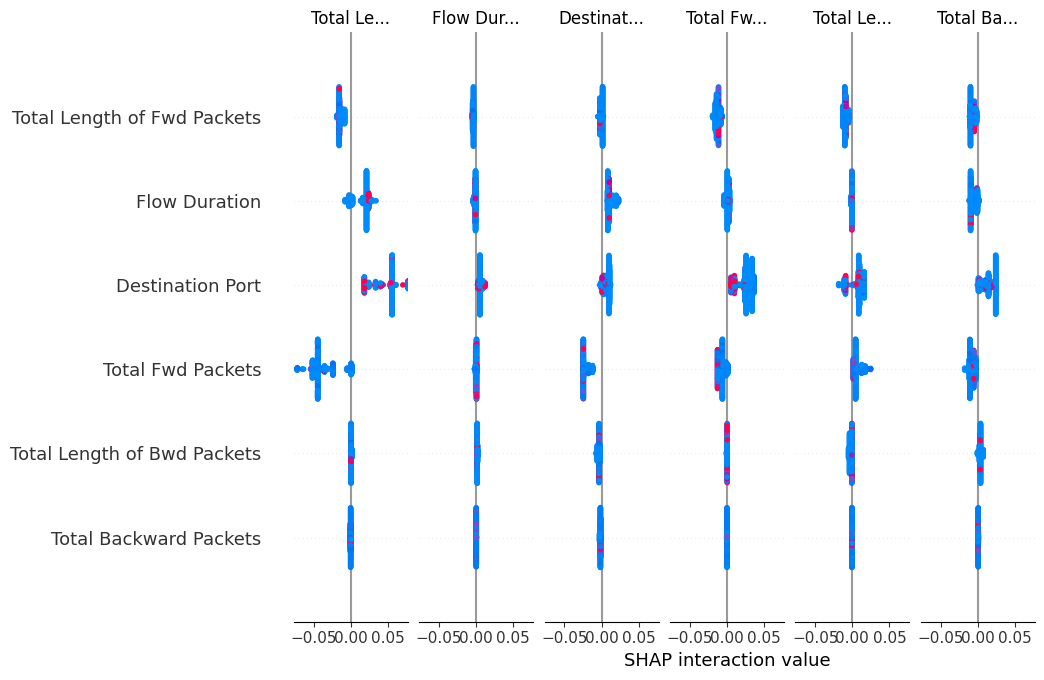

In [49]:
shap.summary_plot(
    shap_values,
    sample,
    feature_names=X.columns
)

In [51]:
import joblib

joblib.dump(rf, "rf_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(encoder, "label_encoder.pkl")

['label_encoder.pkl']

In [52]:
from google.colab import files

files.download("rf_model.pkl")
files.download("scaler.pkl")
files.download("label_encoder.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [53]:
def predict_attack(data):

    data = scaler.transform(data)

    prediction = rf.predict(data)

    label = encoder.inverse_transform(prediction)

    return label[0]

In [54]:
predict_attack(X.iloc[[0]])

'BENIGN'

In [55]:
{
  "PortScan": {
    "severity": "Medium",
    "description": "...",
    "mitigation": "..."
  },

  "DDoS": {
    "severity": "High",
    "description": "...",
    "mitigation": "..."
  }
}

{'PortScan': {'severity': 'Medium', 'description': '...', 'mitigation': '...'},
 'DDoS': {'severity': 'High', 'description': '...', 'mitigation': '...'}}

In [56]:
security_knowledge = {
    "DDoS": {
        "severity": "High",
        "description": "Distributed Denial of Service attack that overwhelms a target with traffic.",
        "mitigation": [
            "Rate limiting",
            "CDN protection",
            "Traffic filtering",
            "Firewall rules"
        ]
    },

    "PortScan": {
        "severity": "Medium",
        "description": "Reconnaissance activity used to discover open ports.",
        "mitigation": [
            "Block suspicious IPs",
            "Enable IDS",
            "Monitor unusual scans"
        ]
    },

    "FTP-Patator": {
        "severity": "High",
        "description": "FTP brute-force attack attempting password guessing.",
        "mitigation": [
            "Strong passwords",
            "Account lockout",
            "MFA"
        ]
    },

    "SSH-Patator": {
        "severity": "High",
        "description": "SSH brute-force attack attempting unauthorized access.",
        "mitigation": [
            "Disable password login",
            "Use SSH keys",
            "Limit login attempts"
        ]
    },

    "Bot": {
        "severity": "High",
        "description": "Compromised machine controlled remotely.",
        "mitigation": [
            "Endpoint protection",
            "Network isolation",
            "Malware scanning"
        ]
    },

    "BENIGN": {
        "severity": "None",
        "description": "Normal network traffic.",
        "mitigation": [
            "No action required"
        ]
    }
}

In [57]:
def generate_security_report(predicted_attack):

    attack_info = security_knowledge[predicted_attack]

    report = f"""
Attack Type: {predicted_attack}

Severity: {attack_info['severity']}

Description:
{attack_info['description']}

Mitigation:
"""

    for item in attack_info["mitigation"]:
        report += f"\n- {item}"

    return report

In [58]:
print(generate_security_report("DDoS"))


Attack Type: DDoS

Severity: High

Description:
Distributed Denial of Service attack that overwhelms a target with traffic.

Mitigation:

- Rate limiting
- CDN protection
- Traffic filtering
- Firewall rules


In [59]:
def predict_and_explain(sample):

    sample_scaled = scaler.transform(sample)

    pred = rf.predict(sample_scaled)

    attack = encoder.inverse_transform(pred)[0]

    print(generate_security_report(attack))

In [60]:
predict_and_explain(X.iloc[[0]])


Attack Type: BENIGN

Severity: None

Description:
Normal network traffic.

Mitigation:

- No action required


In [61]:
import pandas as pd

data = {
    "attack_type": ["DDoS", "PortScan", "Bot", "FTP-Patator", "SSH-Patator"],
    "severity": ["High", "Medium", "High", "High", "High"],
    "description": [
        "Distributed Denial of Service attack",
        "Reconnaissance scan",
        "Compromised machine",
        "FTP brute force attack",
        "SSH brute force attack"
    ],
    "mitigation": [
        "Rate limiting; CDN; Firewall",
        "Block suspicious IPs; IDS",
        "Endpoint protection; Isolation",
        "Strong passwords; MFA",
        "SSH keys; Disable password login"
    ]
}

df = pd.DataFrame(data)
df.to_csv("security_knowledge.csv", index=False)

print("security_knowledge.csv created successfully!")

security_knowledge.csv created successfully!


In [62]:
!pip install sentence-transformers
!pip install faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 98.0 MB/s eta 0:00:00


Create Embeddings

In [63]:
from sentence_transformers import SentenceTransformer
import pandas as pd
import faiss
import numpy as np

kb = pd.read_csv("security_knowledge.csv")

model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

documents = (
    kb["attack_type"]
    + " "
    + kb["description"]
    + " "
    + kb["mitigation"]
).tolist()

embeddings = model.encode(documents)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

**Create FAISS Index**

In [67]:
dimension = embeddings.shape[1]

index = faiss.IndexFlatL2(
    dimension
)

index.add(
    np.array(
        embeddings,
        dtype=np.float32
    )
)

In [69]:
def retrieve_attack_info(
    attack_name
):

    query_embedding = model.encode(
        [attack_name]
    )

    D, I = index.search(
        np.array(
            query_embedding,
            dtype=np.float32
        ),
        k=1
    )

    return kb.iloc[I[0][0]]

In [70]:
result = retrieve_attack_info(
    "DDoS"
)

print(result)

attack_type                                    DDoS
severity                                       High
description    Distributed Denial of Service attack
mitigation             Rate limiting; CDN; Firewall
Name: 0, dtype: object


In [71]:
print(X.iloc[0].tolist())

[53.0, 32399.0, 2.0, 2.0, 62.0, 232.0, 31.0, 31.0, 31.0, 0.0, 116.0, 116.0, 116.0, 0.0, 9074.3541467329, 123.4606006358, 10799.6666666667, 18664.0175828607, 32351.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 48.0, 48.0, 0.0, 48.0, 48.0, 0.0, 0.0, 0.0, 0.0, 64.0, 64.0, 61.7303003179, 61.7303003179, 31.0, 116.0, 65.0, 46.5564173879, 2167.5, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 81.25, 31.0, 116.0, 64.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 2.0, 62.0, 2.0, 232.0, -1.0, -1.0, 1.0, 32.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
